*Importing Libraries*

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Loading dataframe 

In [4]:
data = pd.read_csv(r"C:\Users\AdmiN\Desktop\Project 2\Dataset\customer_shopping_dataset.csv")

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [6]:
data.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


Checking for null values and fixing if null values present


In [7]:
data.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [8]:
# Filling missing value of 'Review Rating' by the median of their respective category mean

data['Review Rating'] = data['Review Rating'].fillna(np.mean(data["Review Rating"]))

changing columns name case for ease

In [9]:
data.columns = data.columns.str.lower()
data.columns = data.columns.str.replace(" ","_")
data.rename(columns={'purchase_amount_(usd)':'purchase_amount'},inplace=True)

Creating New Column 'age_group' and 'purchase_frequency_days'

In [10]:
labels = ['Young Adult','Adult','Middle-Aged','Senior']
data['age_group'] = pd.qcut(data['age'],q=4,labels=labels) 

frequency_mapping = {'Fortnightly':14,
                     'Weekly':7,
                     'Annually':365,
                     'Quarterly':90,
                     'Bi-Weekly':14,
                     'Monthly':30,
                     'Every 3 Months':90}

data['purchase_frequency_days'] = data['frequency_of_purchases'].map(frequency_mapping)

In [11]:
data[['age','age_group']].head(10)

,age,age_group
0,55,Middle-Aged
1,19,Young Adult
2,50,Middle-Aged
3,21,Young Adult
4,45,Middle-Aged
5,46,Middle-Aged
6,63,Senior
7,27,Young Adult
8,26,Young Adult
9,57,Middle-Aged


In [12]:
data[['frequency_of_purchases','purchase_frequency_days']].head(10)

,frequency_of_purchases,purchase_frequency_days
0,Fortnightly,14
1,Fortnightly,14
2,Weekly,7
3,Weekly,7
4,Annually,365
5,Weekly,7
6,Quarterly,90
7,Weekly,7
8,Annually,365
9,Quarterly,90


In [13]:
data[['discount_applied','promo_code_used']].head(10)

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


In [14]:
# checking when discount is applied is promo code is used all time 
(data['discount_applied'] == data['promo_code_used']).all()

np.True_

In [15]:
data.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases', 'age_group',
       'purchase_frequency_days'],
      dtype='object')

1.- Checking Which age customers generating more revenue


C:\Users\AdmiN\AppData\Local\Temp\ipykernel_15220\2722043134.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_revenue = data.groupby('age_group')['purchase_amount'].sum()


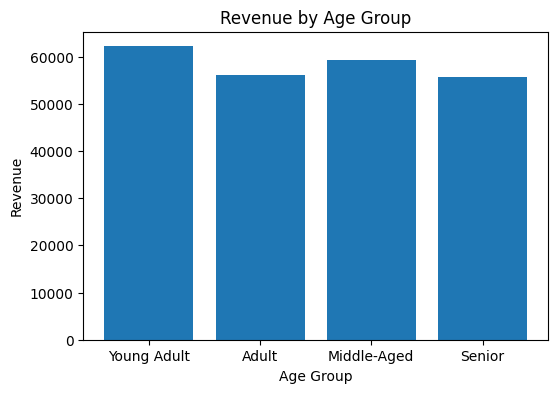

In [16]:
age_revenue = data.groupby('age_group')['purchase_amount'].sum()

plt.figure(figsize=(6,4))
plt.title("Revenue by Age Group")
plt.bar(x=age_revenue.index,height=age_revenue.values)
plt.xlabel("Age Group")
plt.ylabel("Revenue")
plt.show()

checking which Category performing best (Generating more revenue) 

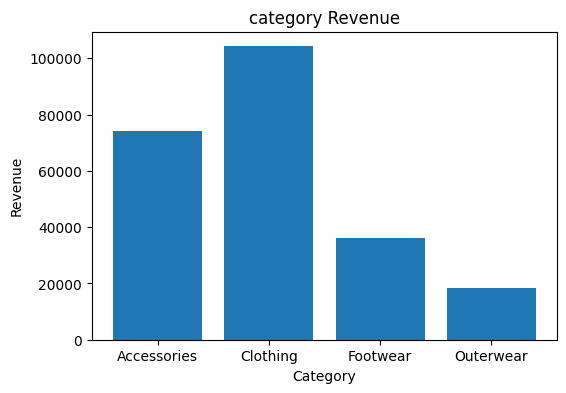

In [17]:
category_revenue = data.groupby('category')['purchase_amount'].sum()

plt.figure(figsize=(6,4))
plt.title("category Revenue")
plt.bar(x=category_revenue.index,height=category_revenue.values)
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.show()

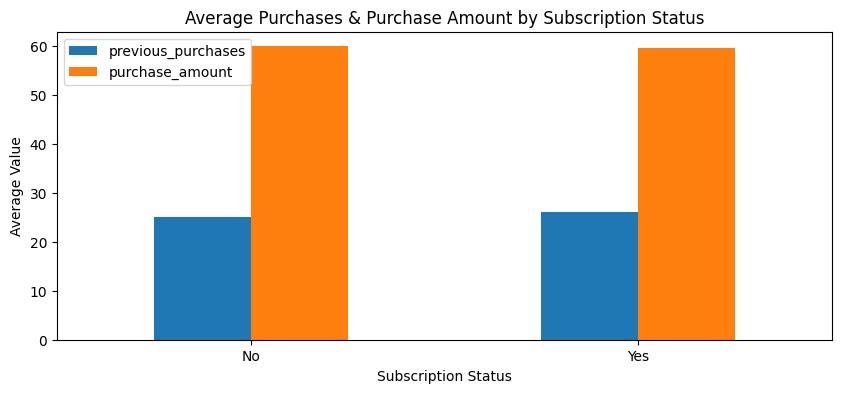

In [27]:
# Does subscribers spend more?
loyalty_analysis = data.groupby('subscription_status')[['previous_purchases', 'purchase_amount']].mean()

ax = loyalty_analysis.plot(kind='bar', figsize=(10,4))

# Labels and title
plt.title("Average Purchases & Purchase Amount by Subscription Status")
plt.xlabel("Subscription Status")
plt.ylabel("Average Value")
plt.legend(loc='upper left')

# Rotate x-labels
plt.xticks(rotation=0)
plt.show()


From the above analysis we find that the subscribers and non subscribers spent identical.


*Finding correaltion between the factors*

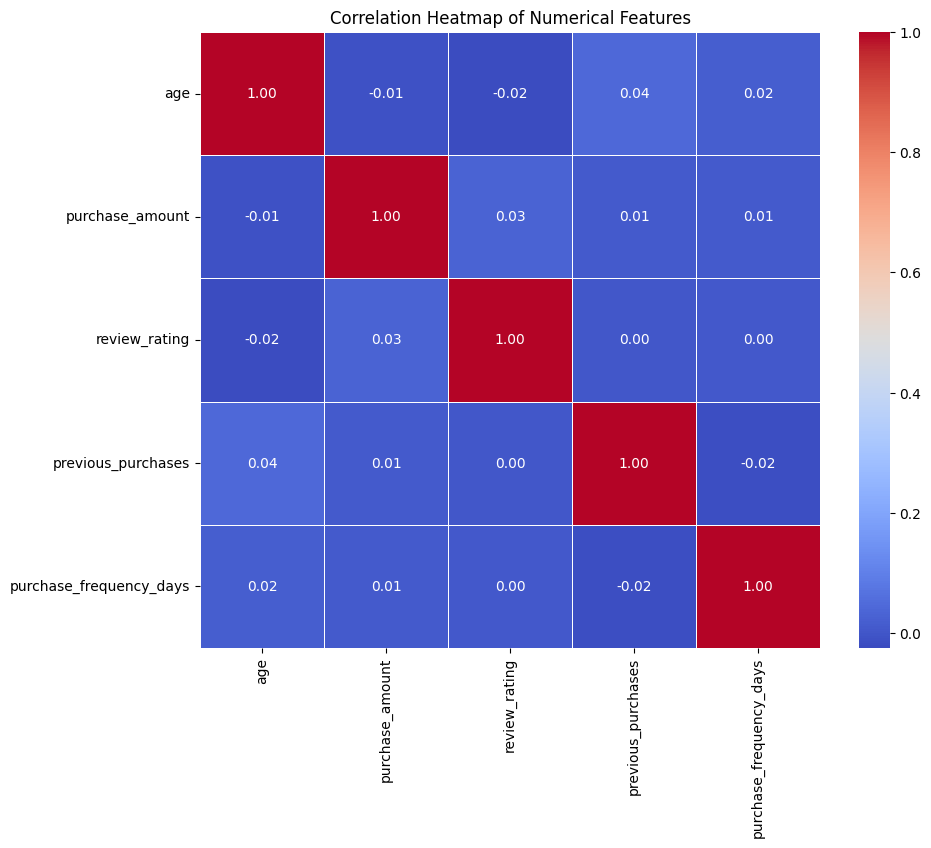

In [38]:
numerical_cols = ['age', 'purchase_amount', 'review_rating', 
                  'previous_purchases', 'purchase_frequency_days']

corr_matrix = data[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True,       
            cmap='coolwarm',  
            fmt=".2f",        
            linewidths=0.5)  

plt.title('Correlation Heatmap of Numerical Features')
plt.show()

From the above correlation heatmap we see that there is not a such extreme correlation between the factors 

connecting jupyter notebook to MySQL database for more analysis(Insights)

In [19]:
from sqlalchemy import create_engine

USER = 'root'
PASSWORD = '8949762644'
HOST = 'localhost'
PORT = '3306'
DATABASE = 'customer_behaviour'

# Create the connection string
connection_string = f'mysql+mysqlconnector://{USER}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}'

# Create the SQLAlchemy engine
try:
    engine = create_engine(connection_string)
    print("Successfully connected to MySQL!")
except Exception as e:
    print(f"Connection failed: {e}")

# Load dataframe into MySQL
table_name = 'customer'
data.to_sql(table_name,engine,if_exists='replace',index=False)

Successfully connected to MySQL!


-1